<a href="https://colab.research.google.com/github/Lavanya-Srinivas214/AU_workshop/blob/main/Heart_disease_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First 5 Rows
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  

Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol    

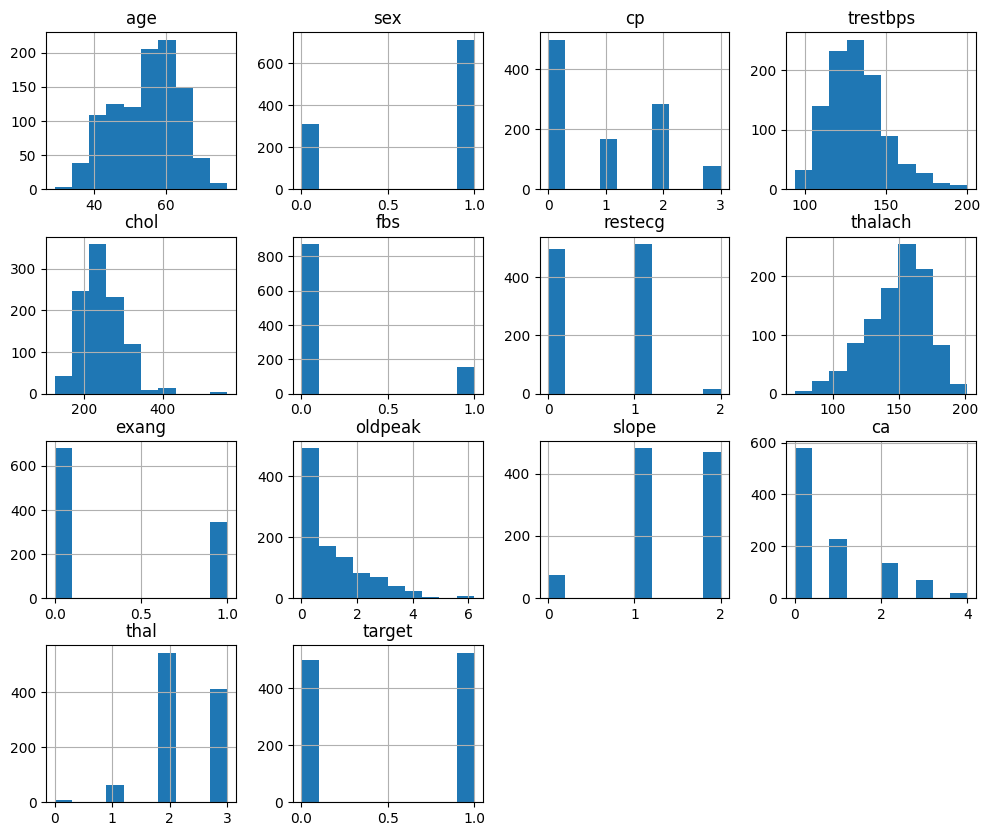

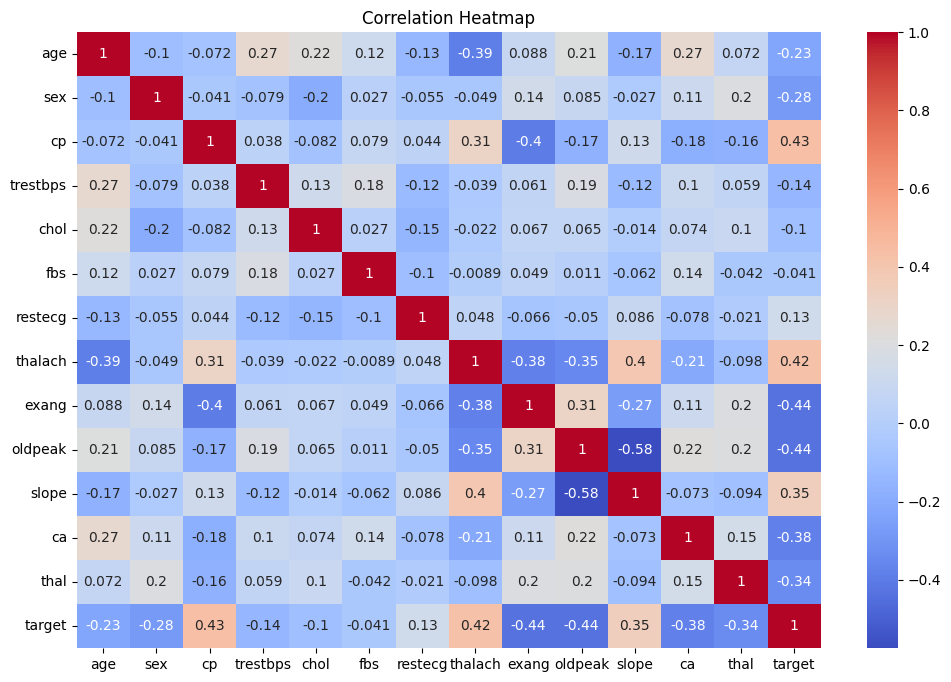


Logistic Regression Results
              precision    recall  f1-score   support

           0       0.84      0.72      0.77       102
           1       0.75      0.86      0.81       103

    accuracy                           0.79       205
   macro avg       0.80      0.79      0.79       205
weighted avg       0.80      0.79      0.79       205

ROC-AUC Score: 0.876070816676185

Random Forest Results
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205

ROC-AUC Score: 1.0

XGBoost Results
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macr

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:05:01] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


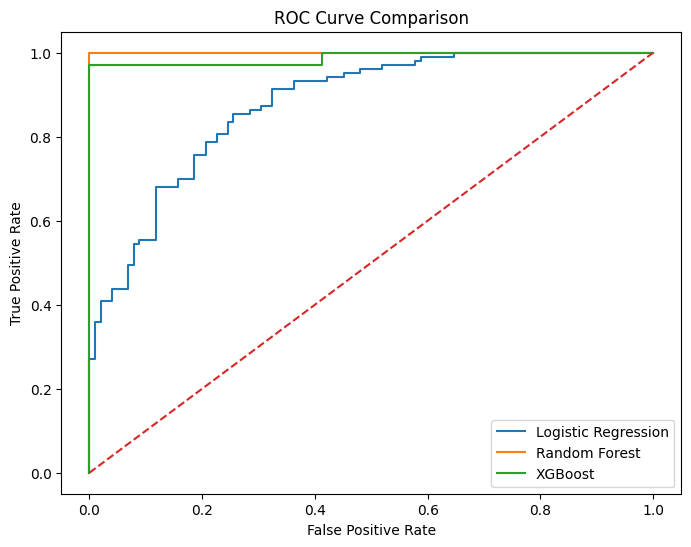

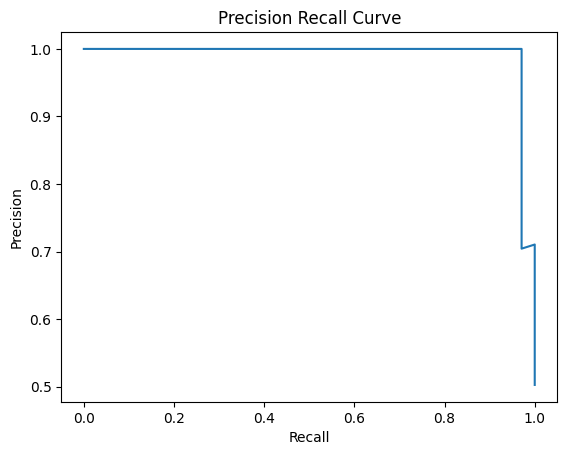

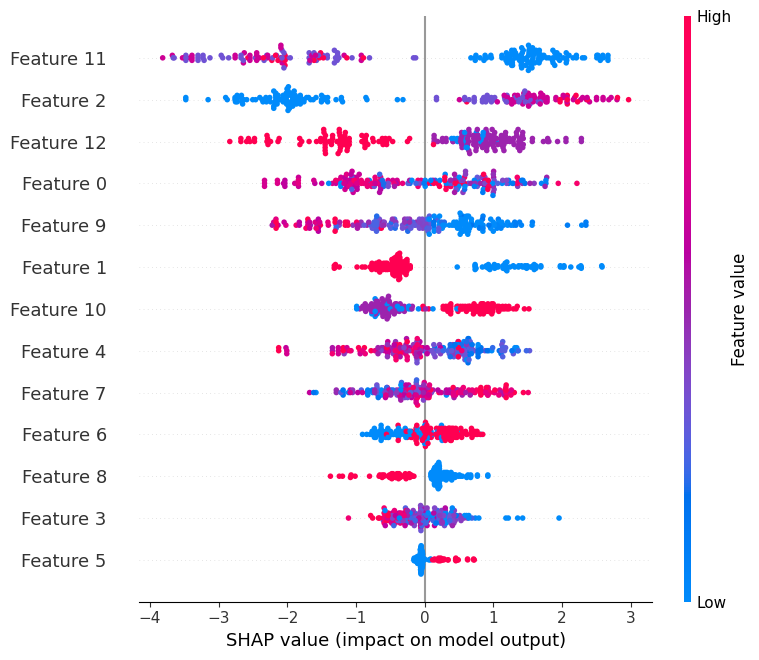


Prediction: Patient HAS Heart Disease


In [6]:
# HEART DISEASE PREDICTION PROJECT

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, precision_recall_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from imblearn.over_sampling import SMOTE
import xgboost as xgb
import shap

# Load Dataset
df = pd.read_csv("heart.csv")

# Display first rows
print("First 5 Rows")
print(df.head())

# Dataset Information
print("\nDataset Info")
print(df.info())

# Check missing values
print("\nMissing Values")
print(df.isnull().sum())


# EDA
# Distribution plots
df.hist(figsize=(12,10))
plt.show()

# Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


# Data Processing
X = df.drop("target", axis=1)
y = df["target"]

# Standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

# Handle Class Imbalance
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)


# Logistic Regression
log_model = LogisticRegression()
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

print("\nLogistic Regression Results")
print(classification_report(y_test, y_pred_log))

roc_log = roc_auc_score(y_test, log_model.predict_proba(X_test)[:,1])
print("ROC-AUC Score:", roc_log)


# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("\nRandom Forest Results")
print(classification_report(y_test, y_pred_rf))

roc_rf = roc_auc_score(y_test, rf_model.predict_proba(X_test)[:,1])
print("ROC-AUC Score:", roc_rf)


# XGBoost
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

print("\nXGBoost Results")
print(classification_report(y_test, y_pred_xgb))

roc_xgb = roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:,1])
print("ROC-AUC Score:", roc_xgb)


# ROC Curve
fpr_log, tpr_log, _ = roc_curve(y_test, log_model.predict_proba(X_test)[:,1])
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_model.predict_proba(X_test)[:,1])
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_model.predict_proba(X_test)[:,1])

plt.figure(figsize=(8,6))
plt.plot(fpr_log, tpr_log, label="Logistic Regression")
plt.plot(fpr_rf, tpr_rf, label="Random Forest")
plt.plot(fpr_xgb, tpr_xgb, label="XGBoost")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()


# Precision Recall Curve
precision, recall, _ = precision_recall_curve(y_test, xgb_model.predict_proba(X_test)[:,1])

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision Recall Curve")
plt.show()


# SHAP Feature Importance
explainer = shap.Explainer(xgb_model)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test)


# Sample Prediction
sample = X_test[0].reshape(1,-1)
prediction = xgb_model.predict(sample)

if prediction[0] == 1:
    print("\nPrediction: Patient HAS Heart Disease")
else:
    print("\nPrediction: Patient does NOT have Heart Disease")